# Финальный прогноз: Logistic Regression + pseudo-labels

Версия **под защиту**.

В ноутбуке оставлена только одна ML-модель — **Logistic Regression**.  
Random Forest удалён, так как он использовался только как экспериментальный вариант.

Идея модели:

- геологические слои переводятся в числовые признаки для ячеек сети;
- реальные точки проявлений/аномалий используются как положительные примеры;
- из `geo_score` берутся только уверенные псевдометки:
  - лучшие зоны — дополнительный положительный класс;
  - слабые зоны — фоновый отрицательный класс;
  - промежуточные зоны не участвуют в обучении;
- итоговая карта строится по `ml_score`.

Сохраняется только итоговый PNG.


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    from scipy.ndimage import gaussian_filter
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

pd.set_option("display.max_columns", 100)


## 1. Настройки

In [ ]:
# ===== ПУТИ =====
BASE_DIR = Path(r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз")
SHP_DIR = BASE_DIR / "shp_dbf"
OUT_DIR = BASE_DIR / "ml_forecast_result"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ===== СЕТКА =====
CELL_SIZE = 500

# ===== PSEUDO-LABELS =====
# Верхние 6% geo_score используются как уверенный положительный класс.
PSEUDO_POS_Q = 0.94

# Нижние 50% geo_score используются как фоновый отрицательный класс.
PSEUDO_NEG_Q = 0.50

# ===== LOGISTIC REGRESSION =====
RANDOM_STATE = 42
LOGREG_C = 1.0
MAX_ITER = 3000

# ===== ФИНАЛЬНАЯ КАРТА =====
# Небольшая стабилизация через geo_score.
# Это не замена ML, а геологическая регуляризация результата.
GEO_STABILIZER = 0.15

# Сглаживание поверхности прогноза.
SMOOTH_SIGMA = 1.25

# Жёлтые зоны — верхние 10% итогового ml_score.
FINAL_ZONE_Q = 0.90

PNG_PATH = OUT_DIR / "final_logreg_pseudolabels_forecast.png"

print("BASE_DIR:", BASE_DIR)
print("SHP_DIR:", SHP_DIR)
print("OUT_DIR:", OUT_DIR)


BASE_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз
SHP_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\shp_dbf
OUT_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\ml_forecast_result


## 2. Функции

In [ ]:
def read_vector(path: Path) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    gdf = gdf[~gdf.geometry.isna()].copy()
    if len(gdf) > 0:
        try:
            gdf["geometry"] = gdf.geometry.buffer(0)
        except Exception:
            pass
        gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def robust_normalize_01(values, q_low=0.02, q_high=0.98, invert=False):
    s = pd.Series(values).astype(float)
    lo = s.quantile(q_low)
    hi = s.quantile(q_high)

    if hi == lo:
        out = np.zeros(len(s), dtype=float)
    else:
        out = ((s - lo) / (hi - lo)).clip(0, 1).to_numpy()

    if invert:
        out = 1 - out

    return out


def find_layer_by_keywords(layer_names, keywords):
    keys = [k.lower() for k in keywords]
    for name in layer_names:
        low = name.lower()
        if any(k in low for k in keys):
            return name
    return None


def make_grid(mask_gdf, cell_size):
    xmin, ymin, xmax, ymax = mask_gdf.total_bounds

    xs = np.arange(xmin, xmax + cell_size, cell_size)
    ys = np.arange(ymin, ymax + cell_size, cell_size)

    geoms = []
    for x in xs[:-1]:
        for y in ys[:-1]:
            geoms.append(box(x, y, x + cell_size, y + cell_size))

    grid = gpd.GeoDataFrame({"geometry": geoms}, crs=mask_gdf.crs)
    mask_union = mask_gdf.geometry.unary_union

    grid = grid[grid.intersects(mask_union)].copy()
    grid["geometry"] = grid.geometry.intersection(mask_union)
    grid = grid[~grid.geometry.is_empty].copy()

    grid["cell_id"] = np.arange(len(grid))
    grid["centroid"] = grid.geometry.centroid

    return grid


def distance_to_layer(grid, layer_gdf):
    if layer_gdf is None or len(layer_gdf) == 0:
        return np.full(len(grid), np.nan)

    union = layer_gdf.geometry.unary_union
    return grid["centroid"].distance(union).to_numpy()


def add_distance_feature(grid, layer_gdf, dist_col, score_col):
    dist = distance_to_layer(grid, layer_gdf)
    grid[dist_col] = dist

    # Ближе к объекту = выше score
    grid[score_col] = robust_normalize_01(dist, invert=True)

    return grid


def collect_point_layers(all_layers, factor_layer_names, target_crs):
    point_parts = []
    factor_set = set([x for x in factor_layer_names if x is not None])

    for name, gdf in all_layers.items():
        if name in factor_set:
            continue
        if len(gdf) == 0:
            continue

        geom_types = set(gdf.geometry.geom_type.unique())

        if geom_types.intersection({"Point", "MultiPoint"}):
            pts = gdf.copy()

            if pts.crs != target_crs:
                pts = pts.to_crs(target_crs)

            pts["source"] = name
            point_parts.append(pts[["source", "geometry"]])

    if not point_parts:
        return None

    points = pd.concat(point_parts, ignore_index=True)
    points = gpd.GeoDataFrame(points, geometry="geometry", crs=target_crs)
    points = points.explode(index_parts=False).reset_index(drop=True)

    return points


def smooth_grid_values(grid, value_col, out_col, sigma):
    if sigma <= 0 or not HAS_SCIPY:
        grid[out_col] = grid[value_col].to_numpy()
        return grid

    cent = grid.geometry.centroid

    xs = np.sort(np.unique(np.round(cent.x.values, 6)))
    ys = np.sort(np.unique(np.round(cent.y.values, 6)))

    x_to_i = {x: i for i, x in enumerate(xs)}
    y_to_j = {y: j for j, y in enumerate(ys)}

    arr = np.full((len(ys), len(xs)), np.nan, dtype=float)

    for idx, row in grid.iterrows():
        c = row.geometry.centroid
        xi = x_to_i[np.round(c.x, 6)]
        yi = y_to_j[np.round(c.y, 6)]
        arr[yi, xi] = row[value_col]

    valid = ~np.isnan(arr)
    filled = np.where(valid, arr, 0.0)
    weight = valid.astype(float)

    smoothed = gaussian_filter(filled, sigma=sigma)
    weights = gaussian_filter(weight, sigma=sigma)
    result = np.where(weights > 0, smoothed / weights, np.nan)

    vals = []
    for idx, row in grid.iterrows():
        c = row.geometry.centroid
        xi = x_to_i[np.round(c.x, 6)]
        yi = y_to_j[np.round(c.y, 6)]
        vals.append(result[yi, xi])

    grid[out_col] = robust_normalize_01(vals, 0.02, 0.98)

    return grid


def recall_at_top_quantile(grid, score_col, positive_cell_ids, top_q=0.90):
    if not positive_cell_ids:
        return np.nan

    threshold = grid[score_col].quantile(top_q)
    top_cells = set(grid.loc[grid[score_col] >= threshold, "cell_id"])
    positive_set = set(positive_cell_ids)

    return len(positive_set.intersection(top_cells)) / max(len(positive_set), 1)


## 3. Загрузка исходных слоёв

In [ ]:
vector_files = []
for ext in ("*.shp", "*.gpkg", "*.geojson", "*.json"):
    vector_files.extend(SHP_DIR.glob(ext))

if not vector_files:
    raise FileNotFoundError(f"В папке не найдены векторные файлы: {SHP_DIR}")

layers = {}

for path in vector_files:
    try:
        name = path.stem
        gdf = read_vector(path)

        if len(gdf) > 0:
            layers[name] = gdf

    except Exception as e:
        print("Не удалось прочитать:", path.name, e)

print("Загруженные слои:")
for name, gdf in layers.items():
    print(f"{name:20s} | n={len(gdf):5d} | geom={list(gdf.geometry.geom_type.unique())}")


Загруженные слои:
dayki_buf            | n=  151 | geom=['Polygon']
fasii                | n=   15 | geom=['Polygon']
glub_raz_nw          | n=    4 | geom=['Polygon']
glub_r_nw            | n=    2 | geom=['Polygon']
gr_dol_vp_poly       | n=    6 | geom=['Polygon']
svita_new            | n=  101 | geom=['Polygon']


## 4. Определение факторных слоёв

In [ ]:
layer_names = list(layers.keys())

aliases = {
    "mask": find_layer_by_keywords(layer_names, ["svita", "свит"]),
    "facies": find_layer_by_keywords(layer_names, ["fasii", "facies", "фаци"]),
    "paleo": find_layer_by_keywords(layer_names, ["gr_dol", "paleo", "дол", "впад"]),
    "struct": find_layer_by_keywords(layer_names, ["kory", "кор"]),
    "magm": find_layer_by_keywords(layer_names, ["dayki", "dyke", "dike", "дай"]),
    "tect_nw": find_layer_by_keywords(layer_names, ["glub_raz", "nw", "сз"]),
    "tect_ne": find_layer_by_keywords(layer_names, ["glub_r", "ne", "св"]),
}

print("Факторные слои:")
for key, value in aliases.items():
    print(f"{key:8s}: {value}")

if aliases["mask"] is None:
    raise ValueError("Не найден слой маски. Укажи aliases['mask'] вручную.")


Факторные слои:
mask    : svita_new
facies  : fasii
paleo   : gr_dol_vp_poly
struct  : None
magm    : dayki_buf
tect_nw : glub_raz_nw
tect_ne : glub_raz_nw


## 5. Сетка и признаки

In [ ]:
mask = layers[aliases["mask"]].copy()

# Приведение CRS факторных слоёв к CRS маски
for key, name in aliases.items():
    if name is not None and layers[name].crs != mask.crs:
        layers[name] = layers[name].to_crs(mask.crs)

grid = make_grid(mask, CELL_SIZE)
grid["sed"] = 1

print("Количество ячеек:", len(grid))

factor_map = {
    "facies": ("dist_facies", "lyth_score"),
    "paleo": ("dist_paleo", "paleo_score"),
    "struct": ("dist_struct", "struct_score"),
    "magm": ("dist_magm", "magm_score"),
    "tect_nw": ("dist_tect_nw", "tect_nw_score"),
    "tect_ne": ("dist_tect_ne", "tect_ne_score"),
}

factor_score_cols = []

for factor_key, (dist_col, score_col) in factor_map.items():
    layer_name = aliases.get(factor_key)
    layer_gdf = layers[layer_name] if layer_name is not None else None

    grid = add_distance_feature(grid, layer_gdf, dist_col, score_col)
    factor_score_cols.append(score_col)

# Взаимодействия факторов для Logistic Regression
grid["tect_best_score"] = grid[["tect_nw_score", "tect_ne_score"]].max(axis=1)
grid["tect_paleo_score"] = grid["tect_best_score"] * grid["paleo_score"]
grid["facies_struct_score"] = grid["lyth_score"] * grid["struct_score"]
grid["magm_struct_score"] = grid["magm_score"] * grid["struct_score"]

interaction_cols = [
    "tect_best_score",
    "tect_paleo_score",
    "facies_struct_score",
    "magm_struct_score",
]

feature_cols = factor_score_cols + interaction_cols

print("Признаки ML:")
for col in feature_cols:
    print(" -", col)

grid[feature_cols].describe()


Количество ячеек: 15684
Признаки ML:
 - lyth_score
 - paleo_score
 - struct_score
 - magm_score
 - tect_nw_score
 - tect_ne_score
 - tect_best_score
 - tect_paleo_score
 - facies_struct_score
 - magm_struct_score


,lyth_score,paleo_score,struct_score,magm_score,tect_nw_score,tect_ne_score,tect_best_score,tect_paleo_score,facies_struct_score,magm_struct_score
count,15684.000000,15684.000000,0.0,15684.000000,15684.000000,15684.000000,15684.000000,15684.000000,0.0,0.0
mean,0.752237,0.764688,NaN,0.695607,0.847500,0.847500,0.847500,0.645927,NaN,NaN
std,0.279637,0.271969,NaN,0.247742,0.231265,0.231265,0.231265,0.301436,NaN,NaN
min,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.599644,0.628377,NaN,0.537600,0.786701,0.786701,0.786701,0.436136,NaN,NaN
50%,0.859772,0.856221,NaN,0.744914,0.952806,0.952806,0.952806,0.701014,NaN,NaN
75%,0.989670,1.000000,NaN,0.901807,1.000000,1.000000,1.000000,0.916412,NaN,NaN
max,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN


## 6. `geo_score` для псевдометок

In [ ]:
weights = {
    "lyth_score": 1.00,
    "paleo_score": 1.15,
    "struct_score": 1.10,
    "magm_score": 0.85,
    "tect_nw_score": 1.00,
    "tect_ne_score": 1.00,
}

weight_sum = sum(weights.values())
geo = np.zeros(len(grid), dtype=float)

for col, weight in weights.items():
    geo += grid[col].fillna(0).to_numpy() * (weight / weight_sum)

coincidence = (
    (grid["lyth_score"] > grid["lyth_score"].quantile(0.70)).astype(float) +
    (grid["paleo_score"] > grid["paleo_score"].quantile(0.70)).astype(float) +
    (grid["struct_score"] > grid["struct_score"].quantile(0.70)).astype(float) +
    (grid["tect_best_score"] > grid["tect_best_score"].quantile(0.70)).astype(float)
) / 4.0

grid["geo_score"] = robust_normalize_01(0.90 * geo + 0.10 * coincidence, 0.02, 0.98)

grid["geo_score"].describe()


count    15684.000000
mean         0.597107
std          0.245237
min          0.000000
25%          0.459140
50%          0.630846
75%          0.783704
max          1.000000
Name: geo_score, dtype: float64

## 7. Реальные точки проявлений / аномалий

In [ ]:
factor_layer_names = list(aliases.values())
points = collect_point_layers(layers, factor_layer_names, mask.crs)

if points is None or len(points) == 0:
    print("Точечные обучающие слои не найдены.")
else:
    print("Количество точек:", len(points))
    display(points["source"].value_counts().to_frame("n"))

    fig, ax = plt.subplots(figsize=(8, 8))
    grid.boundary.plot(ax=ax, linewidth=0.2, color="lightgray")
    points.plot(ax=ax, column="source", markersize=8, legend=True)
    ax.set_title("Точечные данные, используемые как реальные positive-примеры")
    ax.set_axis_off()
    plt.show()


Точечные обучающие слои не найдены.


## 8. Формирование обучающих меток

In [ ]:
grid["target_ml"] = np.nan
positive_cells = []

# Реальные точки = положительный класс
if points is not None and len(points) > 0:
    try:
        joined = gpd.sjoin(
            points[["geometry", "source"]],
            grid[["cell_id", "geometry"]],
            how="left",
            predicate="within",
        )
    except Exception:
        joined = gpd.sjoin(
            points[["geometry", "source"]],
            grid[["cell_id", "geometry"]],
            how="left",
            op="within",
        )

    positive_cells = joined["cell_id"].dropna().astype(int).unique().tolist()
    grid.loc[grid["cell_id"].isin(positive_cells), "target_ml"] = 1

# Pseudo-labels из geo_score
positive_threshold = grid["geo_score"].quantile(PSEUDO_POS_Q)
negative_threshold = grid["geo_score"].quantile(PSEUDO_NEG_Q)

grid.loc[grid["geo_score"] >= positive_threshold, "target_ml"] = 1

negative_mask = (
    (grid["geo_score"] <= negative_threshold)
    & (~grid["cell_id"].isin(positive_cells))
)

grid.loc[negative_mask, "target_ml"] = 0

train = grid.dropna(subset=["target_ml"]).copy()
train["target_ml"] = train["target_ml"].astype(int)

print("Порог positive geo_score:", round(float(positive_threshold), 3))
print("Порог negative geo_score:", round(float(negative_threshold), 3))
print("Обучающих ячеек:", len(train))
print(train["target_ml"].value_counts().rename(index={0: "negative", 1: "positive"}))
print("Реальных positive-ячеек:", len(positive_cells))


Порог positive geo_score: 0.932
Порог negative geo_score: 0.631
Обучающих ячеек: 8783
target_ml
negative    7842
positive     941
Name: count, dtype: int64
Реальных positive-ячеек: 0


## 9. Обучение Logistic Regression

In [ ]:
X_train = train[feature_cols].fillna(0)
y_train = train["target_ml"].astype(int)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=LOGREG_C,
        max_iter=MAX_ITER,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

model.fit(X_train, y_train)

X_all = grid[feature_cols].fillna(0)

grid["lr_score_raw"] = model.predict_proba(X_all)[:, 1]
grid["lr_score"] = robust_normalize_01(grid["lr_score_raw"], 0.02, 0.98)

# Итоговый ML-score.
# Основу составляет Logistic Regression, geo_score используется только как слабая стабилизация.
grid["ml_score_raw"] = (
    (1.0 - GEO_STABILIZER) * grid["lr_score"]
    + GEO_STABILIZER * grid["geo_score"]
)

grid["ml_score_raw"] = robust_normalize_01(grid["ml_score_raw"], 0.02, 0.98)

# Пространственное сглаживание
grid = smooth_grid_values(grid, "ml_score_raw", "ml_score", SMOOTH_SIGMA)

# Для совместимости с логикой методички:
# меньше prognoz = выше перспективность
grid["prognoz"] = 1.0 - grid["ml_score"]

print("Модель обучена.")
print("ml_score min/max:", round(grid["ml_score"].min(), 3), round(grid["ml_score"].max(), 3))


Модель обучена.
ml_score min/max: 0.0 1.0


## 10. Главные метрики

In [ ]:
train_eval = grid.loc[train.index].copy()

y_eval = train_eval["target_ml"].astype(int).to_numpy()
p_eval = train_eval["ml_score"].to_numpy()

roc_auc = roc_auc_score(y_eval, p_eval)
ap = average_precision_score(y_eval, p_eval)
recall_top10 = recall_at_top_quantile(grid, "ml_score", positive_cells, FINAL_ZONE_Q)

metrics = pd.DataFrame([{
    "Model": "Logistic Regression + pseudo-labels",
    "ROC_AUC": round(float(roc_auc), 3),
    "Average_Precision": round(float(ap), 3),
    "Recall_at_Top10_percent": round(float(recall_top10), 3) if not np.isnan(recall_top10) else np.nan,
}])

display(metrics)


,Model,ROC_AUC,Average_Precision,Recall_at_Top10_percent
0,Logistic Regression + pseudo-labels,1.0,1.0,NaN


## 11. Итоговая карта и сохранение PNG

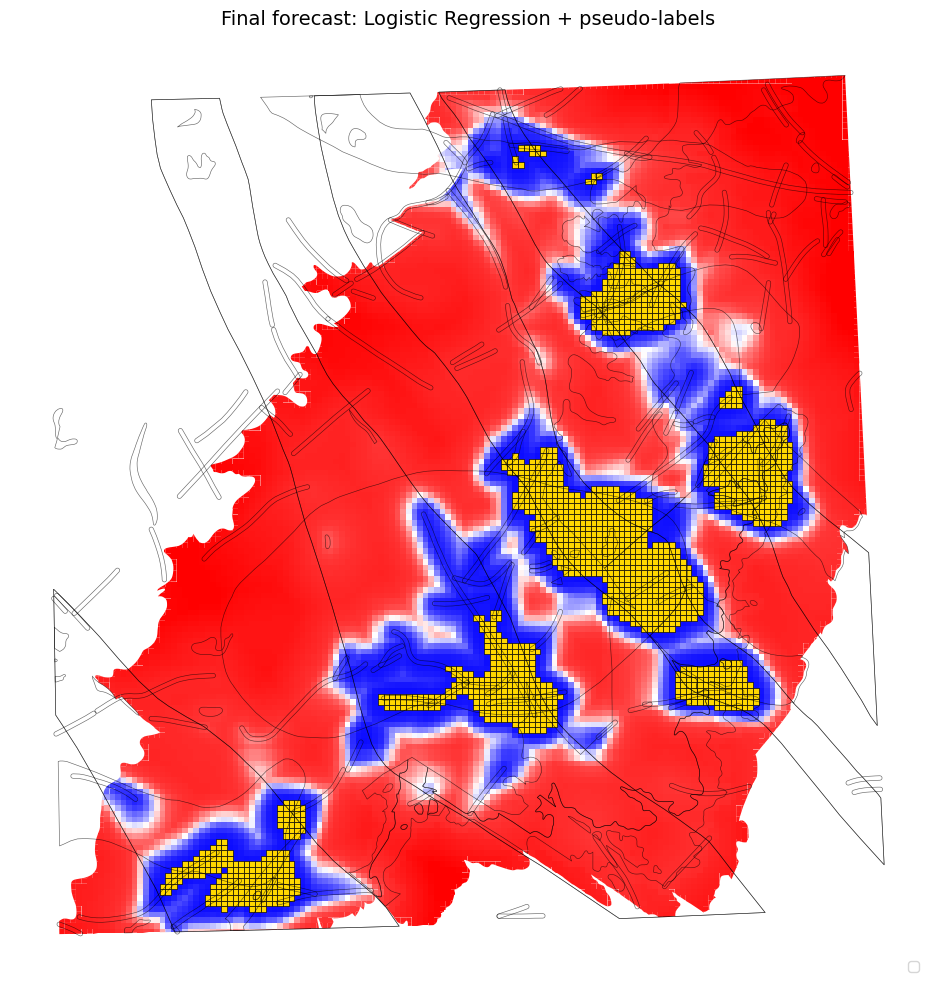

PNG сохранён: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\ml_forecast_result\final_logreg_pseudolabels_forecast.png


In [ ]:
zone_threshold = grid["ml_score"].quantile(FINAL_ZONE_Q)
grid["gold_zone"] = grid["ml_score"] >= zone_threshold

fig, ax = plt.subplots(figsize=(10, 10))

# Синий = перспективнее, красный = менее перспективно
grid.plot(
    column="prognoz",
    ax=ax,
    cmap="bwr",
    linewidth=0,
    legend=False,
)

# Контуры факторов
for key in ["facies", "paleo", "struct", "magm", "tect_nw", "tect_ne"]:
    name = aliases.get(key)

    if name is not None:
        try:
            layers[name].boundary.plot(
                ax=ax,
                color="black",
                linewidth=0.45,
                alpha=0.60,
            )
        except Exception:
            try:
                layers[name].plot(
                    ax=ax,
                    color="none",
                    edgecolor="black",
                    linewidth=0.45,
                    alpha=0.60,
                )
            except Exception:
                pass

# Верхние перспективные зоны
gold = grid[grid["gold_zone"]].copy()

if len(gold) > 0:
    gold.plot(
        ax=ax,
        color="gold",
        edgecolor="black",
        linewidth=0.45,
        label="Gold zone",
    )

ax.set_title("Final forecast: Logistic Regression + pseudo-labels", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(PNG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("PNG сохранён:", PNG_PATH)


## 12. Текст для защиты

В работе использована модель машинного обучения на основе логистической регрессии.  
Такой выбор обусловлен малым числом достоверных точек проявлений и необходимостью получить устойчивую, интерпретируемую поверхность прогноза.

Обучающая выборка сформирована комбинированным способом.  
Известные точки проявлений и аномалий используются как положительный класс.  
Для расширения обучающей выборки применяются псевдометки, сформированные на основе геологически обоснованной критериальной оценки `geo_score`: наиболее перспективные ячейки принимаются как дополнительный положительный класс, а наименее перспективные — как фоновый отрицательный класс.  
Промежуточные ячейки исключаются из обучения, чтобы не вносить неопределённость.

Итоговый прогноз строится по вероятностной оценке `ml_score`, полученной Logistic Regression, с небольшой геологической стабилизацией через `geo_score` и пространственным сглаживанием результата.
